In [1]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 

In [2]:
!ls binaural_eval

test_voice_and_location_word_task_mixed_cue_large_architecture_v03_0dB
test_voice_and_location_word_task_mixed_cue_large_architecture_v04_0dB
test_voice_cue_only_word_task_mixed_cue_large_architecture_0dB
test_voice_cue_only_word_task_mixed_cue_large_architecture_v03_0dB
word_task_mixed_cue_large_architecture_0dB
word_task_voice_loc_cue
word_task_voice_loc_cue_-9dB
word_task_voice_loc_cue_0dB
word_task_voice_loc_cue_9dB


## Model evaluated:
checkpoint: `attn_cue_models/word_task_mixed_cue_large_architecture_v04/checkpoints/epoch=0-step=2000-v14.ckpt`   
config: `config/binaural_attn/word_task_mixed_cue_large_architecture_v04.yml`

In [3]:
# output_paths = Path("binaural_eval/test_voice_and_location_word_task_mixed_cue_large_architecture_v04_0dB").glob("*.pkl")
df

NameError: name 'df' is not defined

In [36]:
# Path to results 
output_paths = Path("/om2/user/rphess/Auditory-Attention/binaural_eval/large_arch_both_cue_11_21/").glob("*.pkl")

stim_manifest_df = pd.read_pickle('/om2/user/rphess/Auditory-Attention/final_binaural_manifest.pkl')

remap_azim = lambda azim: 360 - azim if azim > 90 else 0 - azim 

results_dfs = []

gend_map = {True:'same', False:'diff'}

for path in output_paths:
    res_dict = pickle.load(open(path, 'rb'))
    df = pd.DataFrame.from_dict(res_dict)
    
    df.rename(columns={"results": "accuracy"}, inplace=True)
    # merge with stim manifest
    df = df.join(stim_manifest_df[['word', 'bg_word','gender', 'bg_gender']], how='outer')  
    df["target_azim"], df["target_elev"] = path.stem.split('target_loc_')[1].split('_distract_loc_')[0].split('_')
    df["distractor_azim"], df["distractor_elev"] = path.stem.split('_distract_loc_')[1].split('_')  
    df['gender_cond'] = df["gender"].values == df['bg_gender'].values
    df['gender_cond'] =  df['gender_cond'].map(gend_map)
    # map azim to 0-180
    df['target_azim'] = df['target_azim'].astype(int).apply(remap_azim)
    df['distractor_azim'] = df['distractor_azim'].astype(int).apply(remap_azim)
    
    results_dfs.append(df)
results = pd.concat(results_dfs)

In [37]:
# convert to int
results['target_azim'] = results['target_azim'].astype(int)
results['distractor_azim'] = results['distractor_azim'].astype(int)
results['target_elev'] = results['target_elev'].astype(int)
results['distractor_elev'] = results['distractor_elev'].astype(int)

In [38]:
# results = results.groupby(['gender_cond', 'target_azim', 'distractor_azim', 'target_elev', 'distractor_elev']).agg({'accuracy': ['mean', 'std'], 'confusions': ['mean', 'std']}).reset_index()

In [39]:

# results["elevation_cond"] = results.apply(lambda row: f"target {row.target_elev} distractor {row.distractor_elev}", axis=1)
results['elevation_sep'] = results.target_elev - results.distractor_elev
results['abs_elevation_sep'] = results.elevation_sep.abs()
results['elevated_source'] = results.elevation_sep.apply(lambda x: 'target' if x > 0 else 'distractor' if x < 0 else 'co-located') 

In [43]:
# rename columns
results.rename(columns={'accuracy':'word_acc'}, inplace=True)

# Confusion matrices for target vs distractor location 
## Spatial conditions
### target vs distractor azimuth - columns are different elevation conditions 

In [45]:
results.target_azim.unique()


array([  0, -10, -20])

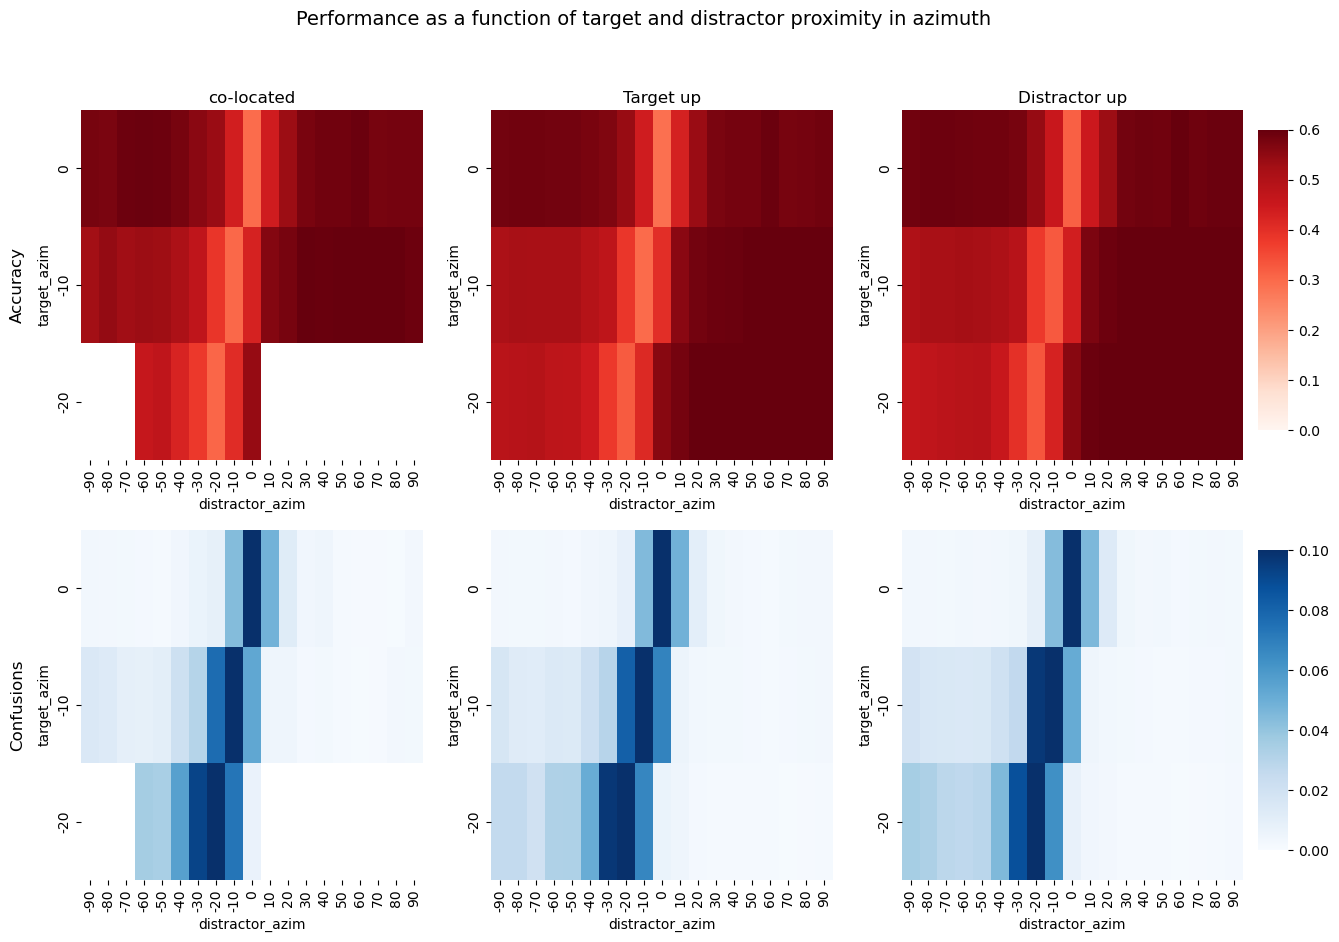

In [44]:
# plot all plots so far onto one figure
cols = ['co-located', 'Target up', 'Distractor up']
rows = ['Accuracy', 'Confusions']

fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharex=False, sharey=False)

cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])

co_loc_acc = results[(results.target_elev == 0) & (results.distractor_elev == 0) ].groupby(["target_azim", "distractor_azim"]).mean()['word_acc']
sns.heatmap(co_loc_acc.unstack(), vmin=0, vmax=0.6, cmap='Reds', cbar=True, cbar_ax=cbar_ax_1, ax=axs[0, 0])
co_loc_con = results[(results.target_elev == 0) & (results.distractor_elev == 0) ].groupby(['target_azim', 'distractor_azim']).mean()['confusions']
sns.heatmap(co_loc_con.unstack(), vmin=0, vmax=0.1, cmap='Blues', cbar=True, cbar_ax=cbar_ax_2, ax=axs[1, 0])

target_up = results[results.target_elev > results.distractor_elev  ]
target_up_acc = target_up.groupby(['target_azim', 'distractor_azim'])['word_acc'].mean()
sns.heatmap(target_up_acc.unstack(), vmin=0, vmax= 0.6, cmap='Reds', cbar=False, cbar_ax=None, ax=axs[0, 1])
target_up_con = target_up.groupby(['target_azim', 'distractor_azim'])['confusions'].mean()
sns.heatmap(target_up_con.unstack(), vmin=0, vmax=0.1, cmap='Blues', cbar=False, cbar_ax=None, ax=axs[1, 1])

target_down = results[results.target_elev < results.distractor_elev  ]
target_down_acc = target_down.groupby(['target_azim', 'distractor_azim'])['word_acc'].mean()
sns.heatmap(target_down_acc.unstack(), vmin=0, vmax=0.6, cmap='Reds', cbar=False, cbar_ax=None, ax=axs[0, 2])
target_down_con = target_down.groupby(['target_azim', 'distractor_azim'])['confusions'].mean()
sns.heatmap(target_down_con.unstack(), vmin=0, vmax=0.1, cmap='Blues', cbar=False, cbar_ax=None, ax=axs[1, 2])

for ax, col in zip(axs[0], cols):
    ax.annotate(col, xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
for ax, row in zip(axs[:, 0], rows):
    ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

# fig.tight_layout(rect=[0,0,.9,1])
plt.suptitle('Performance as a function of target and distractor proximity in azimuth', fontsize=14, y=0.98);

for ax in axs.flatten():
    ax.invert_yaxis()


### Target vs distractor elevation, columns are different target azimuthal deltas 

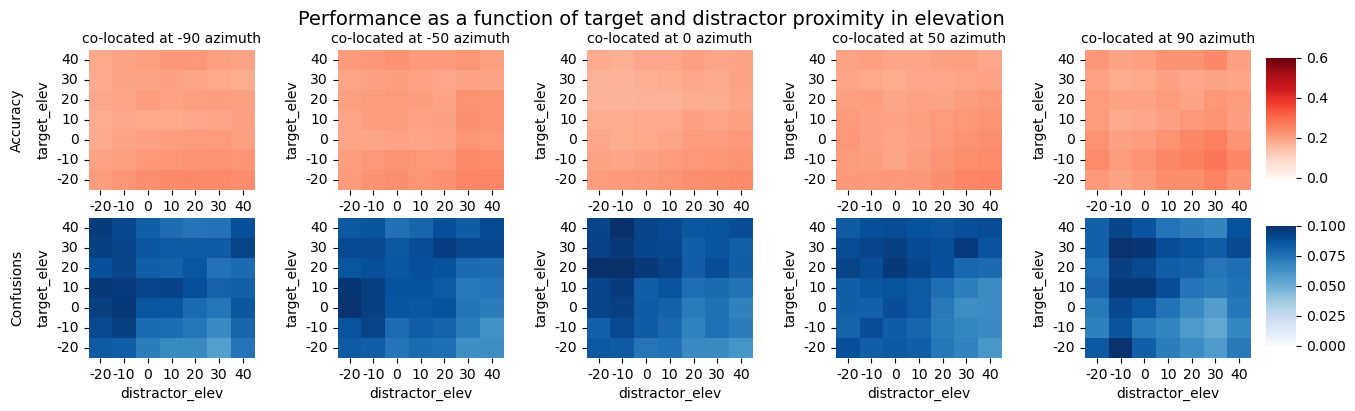

In [9]:
# plot all plots so far onto one figure
cols = ['co-located at 0,0', 'co-located at 90-90']
rows = ['Accuracy', 'Confusions']

fig, axs = plt.subplots(2, 5, figsize=(15, 4), sharex=False, sharey=False)

cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])

wanted_azims = [-90, -50, 0, 50, 90]

for ix, azim in enumerate(wanted_azims):
    co_loc_acc = results[(results.target_azim == azim) & (results.distractor_azim == azim) ].groupby(["target_elev", "distractor_elev"]).mean()['word_acc']
    sns.heatmap(co_loc_acc.unstack(), vmin=0, vmax=0.6, cmap='Reds', cbar=True, cbar_ax=cbar_ax_1, ax=axs[0, ix])
    co_loc_con = results[(results.target_azim == azim) & (results.distractor_azim == azim) ].groupby(['target_elev', 'distractor_elev']).mean()['confusions']
    sns.heatmap(co_loc_con.unstack(), vmin=0, vmax=0.1, cmap='Blues', cbar=True, cbar_ax=cbar_ax_2, ax=axs[1, ix])

fontsize = 10
for ax, azim in zip(axs[0], wanted_azims):
    ax.annotate(f"co-located at {azim} azimuth", xy=(0.5, 1), xytext=(0, 5), size=fontsize, ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
for ax, row in zip(axs[:, 0], rows):
    ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size=fontsize, ha='right', va='center', rotation=90)

# add space between panels
fig.subplots_adjust(wspace=0.5)

# fig.tight_layout(rect=[0,0,.9,1])
plt.suptitle('Performance as a function of target and distractor proximity in elevation', fontsize=14, y=0.98);

for ax in axs.flatten():
    ax.invert_yaxis()


### target vs distractor azimuth - columns are different sex conditions 

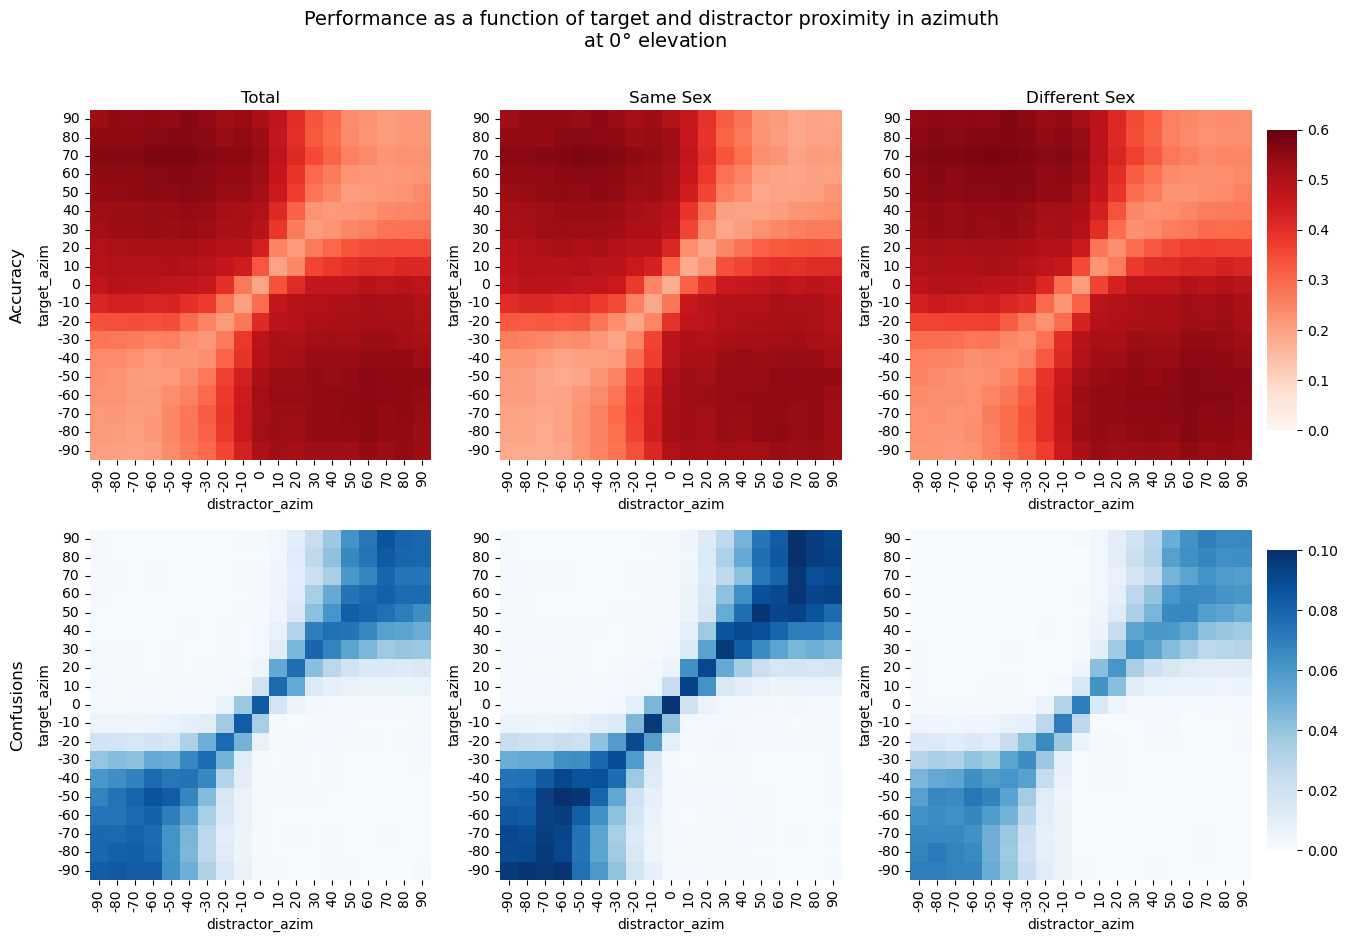

In [10]:
# plot all plots so far onto one figure
cols = ['Total', 'Same Sex', 'Different Sex']
rows = ['Accuracy', 'Confusions']

fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharex=False, sharey=False)

cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])

total_acc = results.groupby(["target_azim", "distractor_azim"]).mean()['word_acc']
sns.heatmap(total_acc.unstack(), vmin=0, vmax=0.6, cmap='Reds', cbar=True, cbar_ax=cbar_ax_1, ax=axs[0, 0])
total_con = results.groupby(['target_azim', 'distractor_azim']).mean()['confusions']
sns.heatmap(total_con.unstack(), vmin=0, vmax=0.1, cmap='Blues', cbar=True, cbar_ax=cbar_ax_2, ax=axs[1, 0])

same_sex = results[results.sex_cond == 'same']
same_sex_acc = same_sex.groupby(['target_azim', 'distractor_azim'])['word_acc'].mean()
sns.heatmap(same_sex_acc.unstack(), vmin=0, vmax= 0.6, cmap='Reds', cbar=False, cbar_ax=None, ax=axs[0, 1])
same_sex_con = same_sex.groupby(['target_azim', 'distractor_azim'])['confusions'].mean()
sns.heatmap(same_sex_con.unstack(), vmin=0, vmax=0.1, cmap='Blues', cbar=False, cbar_ax=None, ax=axs[1, 1])

diff_sex = results[results.sex_cond == 'diff']
diff_sex_acc = diff_sex.groupby(['target_azim', 'distractor_azim'])['word_acc'].mean()
sns.heatmap(diff_sex_acc.unstack(), vmin=0, vmax=0.6, cmap='Reds', cbar=False, cbar_ax=None, ax=axs[0, 2])
diff_sex_con = diff_sex.groupby(['target_azim', 'distractor_azim'])['confusions'].mean()
sns.heatmap(diff_sex_con.unstack(), vmin=0, vmax=0.1, cmap='Blues', cbar=False, cbar_ax=None, ax=axs[1, 2])

for ax, col in zip(axs[0], cols):
    ax.annotate(col, xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
for ax, row in zip(axs[:, 0], rows):
    ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

# fig.tight_layout(rect=[0,0,.9,1])
plt.suptitle('Performance as a function of target and distractor proximity in azimuth\n at $0\degree$ elevation', fontsize=14, y=0.98);

for ax in axs.flatten():
    ax.invert_yaxis()


In [11]:
total_acc.max()

0.5723067173637515

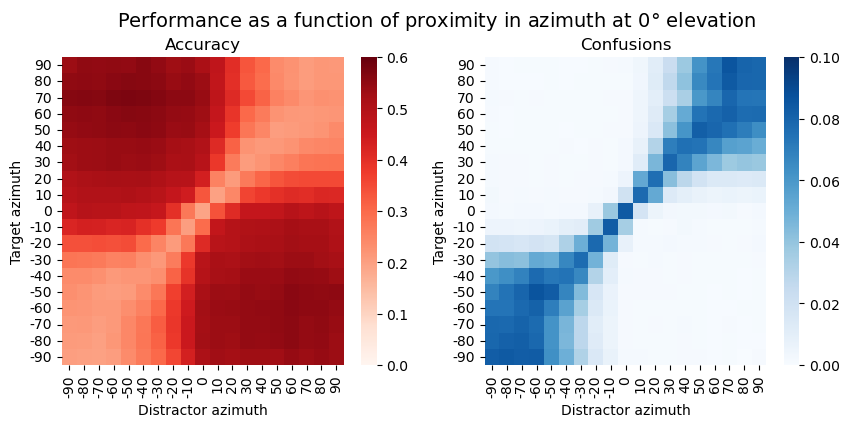

In [12]:
# New results using updated checkpoint epoch=0-step=2000-v2.ckpt

# plot all plots so far onto one figure
cols = ['Total', 'Same Sex', 'Different Sex']
rows = ['Accuracy', 'Confusions']

fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharex=False, sharey=False)

# cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
# cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])

total_acc = results.groupby(["target_azim", "distractor_azim"]).mean()['word_acc']
sns.heatmap(total_acc.unstack(), vmin=0, vmax=0.6, cmap='Reds', cbar=True,  ax=axs[0])

total_con = results.groupby(['target_azim', 'distractor_azim']).mean()['confusions']
sns.heatmap(total_con.unstack(), vmin=0, vmax=0.1, cmap='Blues', cbar=True,ax=axs[1])

# for ax, col in zip(axs[0], cols):
#     ax.annotate(col, xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
# for ax, row in zip(axs[:, 0], rows):
#     ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

# fig.tight_layout(rect=[0,0,.9,1])

axs[0].set_title("Accuracy", )#xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
# for ax, row in zip(axs[1], rows):
axs[1].set_title("Confusions")
axs[0].set_ylabel("Target azimuth")
axs[1].set_ylabel("Target azimuth")
axs[0].set_xlabel("Distractor azimuth")
axs[1].set_xlabel("Distractor azimuth")


plt.suptitle('Performance as a function of proximity in azimuth at $0\degree$ elevation', fontsize=14, y=1);

for ax in axs.flatten():
    ax.invert_yaxis()

# plt.savefig("prelim_binaural_figs/avg_perf_confusion_at_0_elev.pdf", bbox_inches="tight")

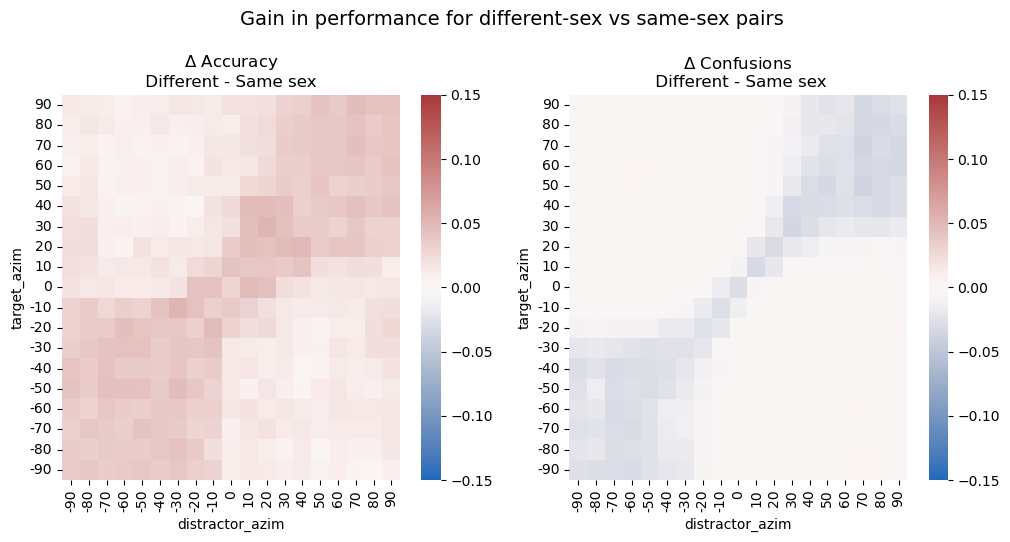

In [13]:
# plot all plots so far onto one figure
# cols = ['Total', 'Same Sex', 'Different Sex']
# rows = ['word_acc', 'Confusions']

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)

# cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
# cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])

diff_sex = results[results.sex_cond == 'diff']
same_sex = results[results.sex_cond == 'same']

diff = diff_sex.groupby(["target_azim", "distractor_azim"])['word_acc'].mean() - same_sex.groupby(["target_azim", "distractor_azim"])['word_acc'].mean()
sns.heatmap(diff.unstack(), vmin=-0.15, vmax=0.15, cmap='vlag', cbar=True, ax=axs[0]) #  cbar_ax=cbar_ax_1,

diff = diff_sex.groupby(["target_azim", "distractor_azim"])['confusions'].mean() - same_sex.groupby(["target_azim", "distractor_azim"])['confusions'].mean()
sns.heatmap(diff.unstack(), vmin=-0.15, vmax=0.15, cmap='vlag', cbar=True,  ax=axs[1]) # cbar_ax=cbar_ax_2,

# for ax, col in zip(axs[0], cols):
axs[0].set_title("$\Delta$ Accuracy \n Different - Same sex ", )#xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
# for ax, row in zip(axs[1], rows):
axs[1].set_title("$\Delta$ Confusions \n Different - Same sex") # , xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

# fig.tight_layout(rect=[0,0,.9,1])
plt.suptitle('Gain in performance for different-sex vs same-sex pairs', fontsize=14, y=1.05);

for ax in axs.flatten():
    ax.invert_yaxis()

# plt.savefig("prelim_binaural_figs/diff_min_same_confusion_at_0_elev.pdf", bbox_inches="tight")

# Line plots
## Plot performance as function of separation between target and distractor 

In [14]:
results['abs_target_azim'] = results.target_azim.abs()
results['abs_distractor_azim'] = results.distractor_azim.abs()

results['azim_delta'] = results.target_azim - results.distractor_azim
results['abs_azim_delta'] = (results.target_azim - results.distractor_azim).abs()

In [15]:
results.head()

,sex_pairing,target_azim,target_elev,distractor_azim,distractor_elev,word_acc,word_error,confusions,confusion_error,elevation_cond,elevation_sep,abs_elevation_sep,elevated_source,sex_cond,abs_target_azim,abs_distractor_azim,azim_delta,abs_azim_delta
0,m_m,0,-10,0,-10,0.200253,0.014256,0.096324,0.010510,target -10 distractor -10,0,0,co-located,same,0,0,0,0
0,m_f,0,-10,0,-10,0.205323,0.014390,0.086185,0.009997,target -10 distractor -10,0,0,co-located,diff,0,0,0,0
0,f_m,0,-10,0,-10,0.209125,0.014488,0.069708,0.009072,target -10 distractor -10,0,0,co-located,diff,0,0,0,0
0,f_f,0,-10,0,-10,0.148289,0.012660,0.108999,0.011102,target -10 distractor -10,0,0,co-located,same,0,0,0,0
0,m_m,0,-10,0,-20,0.200253,0.014256,0.092522,0.010322,target -10 distractor -20,10,10,target,same,0,0,0,0


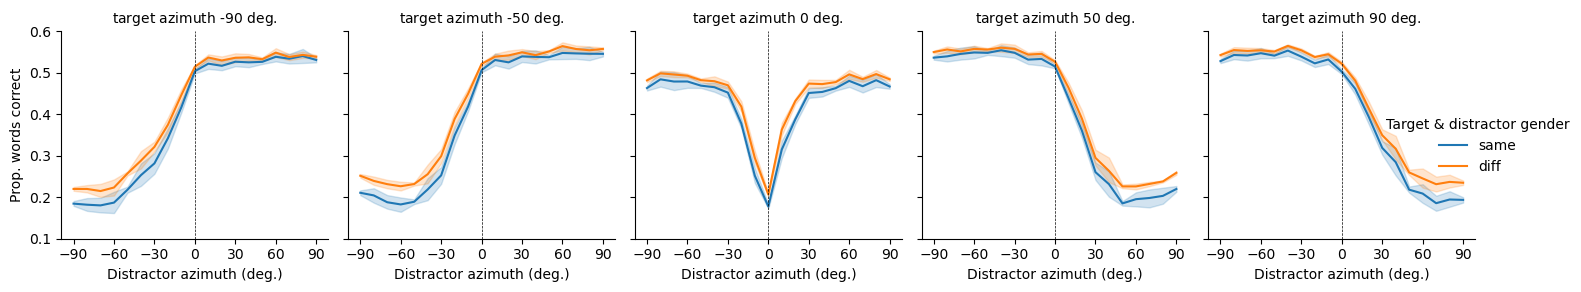

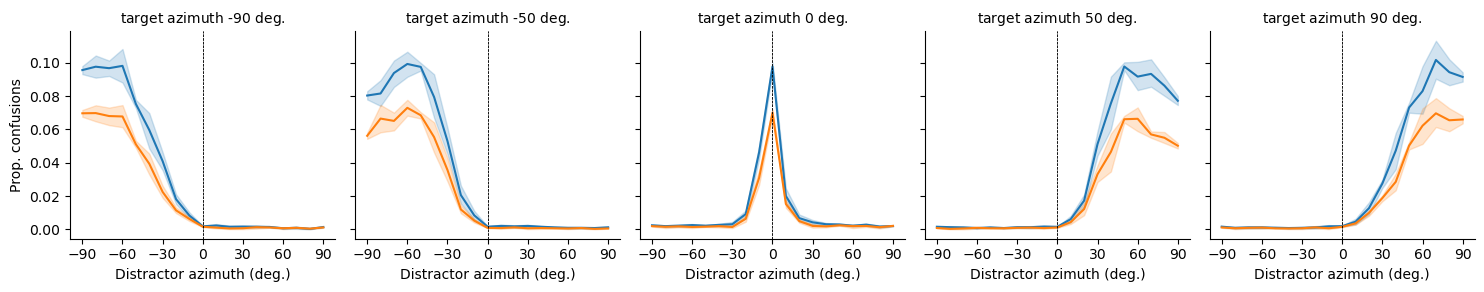

In [16]:

# fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)

# to_plot = results[results.target_azim.isin([0, 30, 60, 90])]
to_plot = results[results.abs_target_azim.isin([0, 50, 90])]

g = sns.relplot(data=to_plot, x='distractor_azim', y='word_acc', hue='sex_cond', col='target_azim', kind='line', height=3)
# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
g.set_axis_labels("Distractor azimuth (deg.)", "Prop. words correct")
g.set_titles("target azimuth {col_name} $\deg.$")
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-90, 91, 30),yticks=np.arange(0.1,0.61, 0.1))

# change legend title 
g.legend.set_title('Target & distractor gender')



g = sns.relplot(data=to_plot, x='distractor_azim', y='confusions', hue='sex_cond', col='target_azim', kind='line',  height=3)
# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)


g.set_axis_labels("Distractor azimuth (deg.)", "Prop. confusions")
g.set_titles("target azimuth {col_name} $\deg.$")
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-90, 91, 30))
g.legend.remove()
# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)


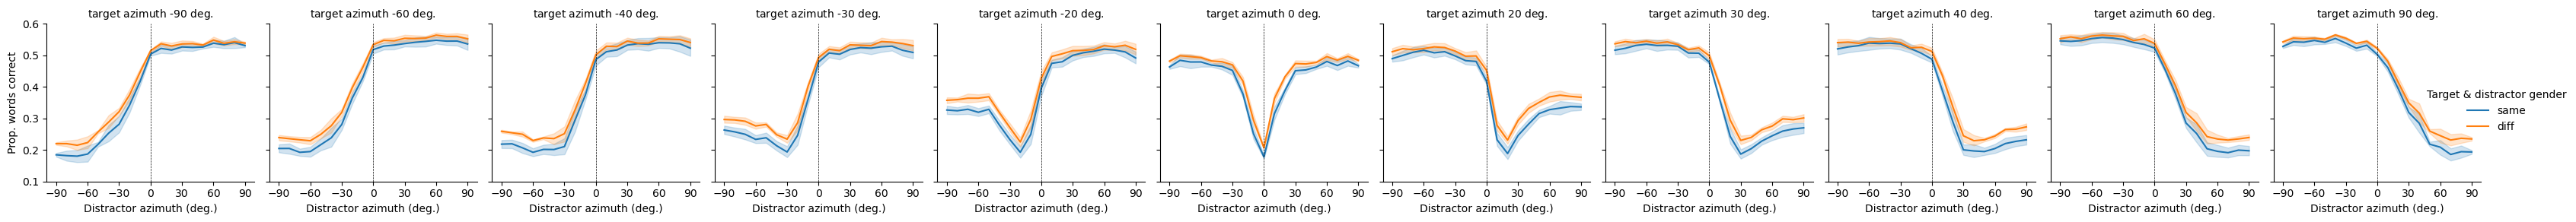

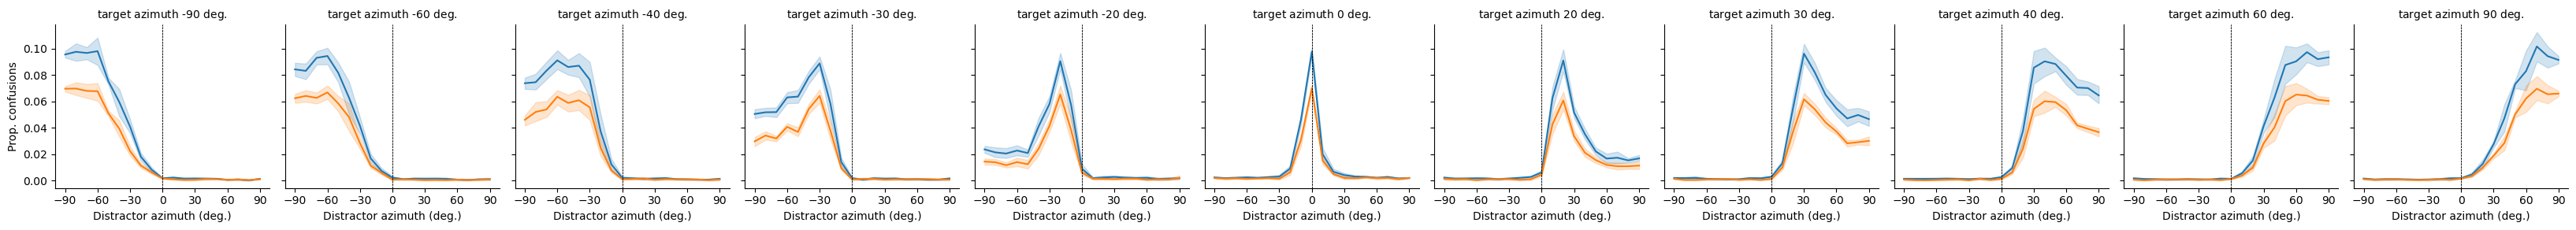

In [18]:

# fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)

# to_plot = results[results.target_azim.isin([0, 30, 60, 90])]
to_plot = results[results.abs_target_azim.isin([0, 20, 30, 40, 60, 90])]

g = sns.relplot(data=to_plot, x='distractor_azim', y='word_acc', hue='sex_cond', col='target_azim', kind='line', height=3)
# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
g.set_axis_labels("Distractor azimuth (deg.)", "Prop. words correct")
g.set_titles("target azimuth {col_name} $\deg.$")
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-90, 91, 30),yticks=np.arange(0.1,0.61, 0.1))

# change legend title 
g.legend.set_title('Target & distractor gender')



g = sns.relplot(data=to_plot, x='distractor_azim', y='confusions', hue='sex_cond', col='target_azim', kind='line',  height=3)
# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)


g.set_axis_labels("Distractor azimuth (deg.)", "Prop. confusions")
g.set_titles("target azimuth {col_name} $\deg.$")
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-90, 91, 30))
g.legend.remove()
# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)


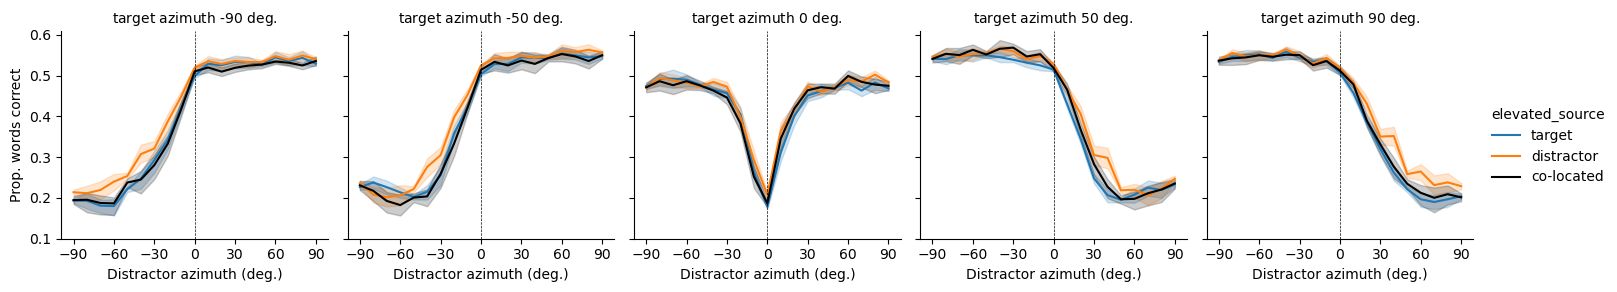

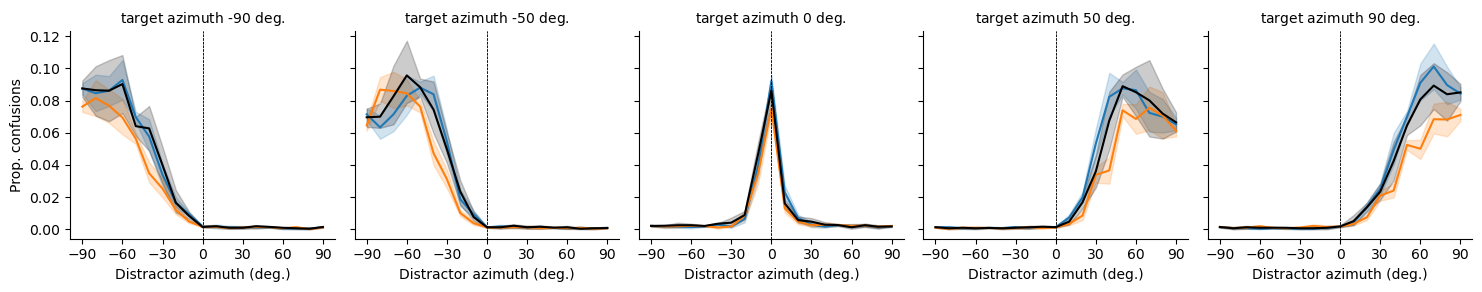

In [17]:

# fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)

# to_plot = results[results.abs_target_azim.isin([0, 30, 60, 90])]
to_plot = results[results.abs_target_azim.isin([0, 50, 90])]
hue_order = ['target', 'distractor', 'co-located']

g = sns.relplot(data=to_plot, x='distractor_azim', y='word_acc', hue='elevated_source', hue_order=hue_order, palette=['tab:blue', 'tab:orange', 'black'] ,
                col='target_azim', kind='line', height=3)
# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
g.set_axis_labels("Distractor azimuth (deg.)", "Prop. words correct")
g.set_titles("target azimuth {col_name} $\deg.$")
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-90, 91, 30),yticks=np.arange(0.1,0.61, 0.1))

# change legend title 
# g.legend.set_title('Abs elveation delta')



g = sns.relplot(data=to_plot, x='distractor_azim', y='confusions', hue='elevated_source', hue_order=hue_order, palette=['tab:blue', 'tab:orange', 'black'],
                col='target_azim', kind='line',  height=3)
# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)


g.set_axis_labels("Distractor azimuth (deg.)", "Prop. confusions")
g.set_titles("target azimuth {col_name} $\deg.$")
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-90, 91, 30))
g.legend.remove()
# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)


In [18]:
to_plot.columns

Index(['sex_pairing', 'target_azim', 'target_elev', 'distractor_azim',
       'distractor_elev', 'word_acc', 'word_error', 'confusions',
       'confusion_error', 'elevation_cond', 'elevation_sep',
       'abs_elevation_sep', 'elevated_source', 'sex_cond', 'abs_target_azim',
       'abs_distractor_azim', 'azim_delta', 'abs_azim_delta'],
      dtype='object')

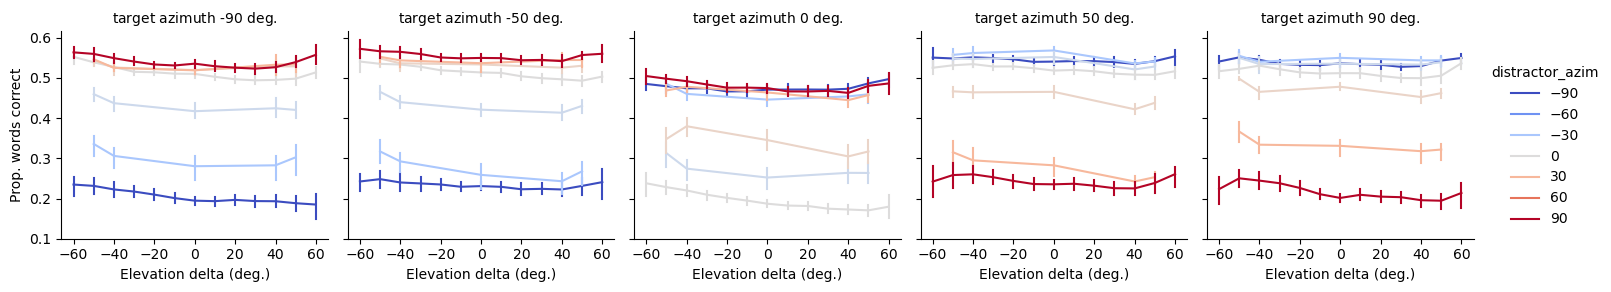

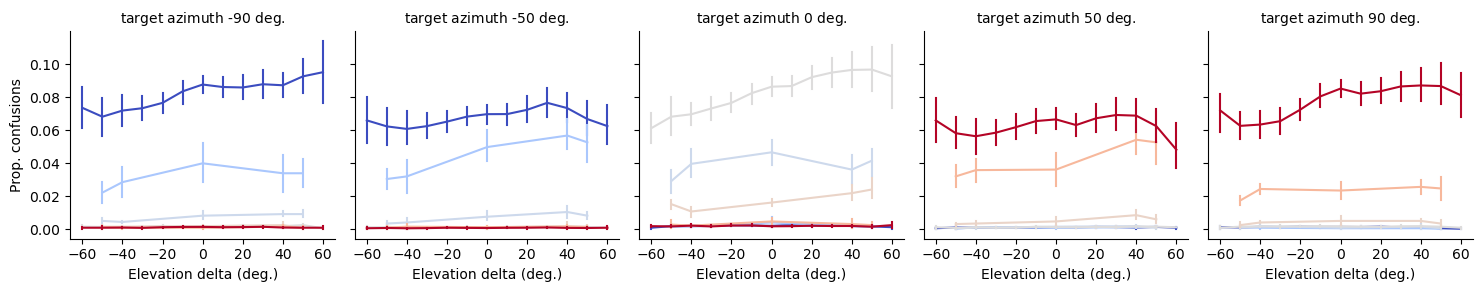

In [39]:
# fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)

# to_plot = results[results.target_azim.isin([0, 30, 60, 90])]
to_plot = results[results.abs_target_azim.isin([0, 50, 90])]
to_plot = to_plot[to_plot.abs_distractor_azim.isin([0, 10, 30, 90])]

hue_order = ['target', 'distractor', 'co-located']
# diverging palette
palette = sns.color_palette("coolwarm", as_cmap=True)

g = sns.relplot(data=to_plot, x='elevation_sep', y='word_acc', hue='distractor_azim', err_style='bars', palette=palette,
                col='target_azim', kind='line', height=3)
# add x line at 0 
# for ax in g.axes.flatten():
#     ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
g.set_axis_labels("Elevation delta (deg.)", "Prop. words correct")
g.set_titles("target azimuth {col_name} $\deg.$")
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-60, 61, 20),yticks=np.arange(0.1,0.61, 0.1))

g = sns.relplot(data=to_plot, x='elevation_sep', y='confusions', hue='distractor_azim', err_style='bars', palette=palette,
                col='target_azim', kind='line',  height=3)
# add x line at 0 
# for ax in g.axes.flatten():
#     ax.axvline(0, color='black', linestyle='--', linewidth=0.5)


g.set_axis_labels("Elevation delta (deg.)", "Prop. confusions")
g.set_titles("target azimuth {col_name} $\deg.$")
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-60, 61, 20))
g.legend.remove()


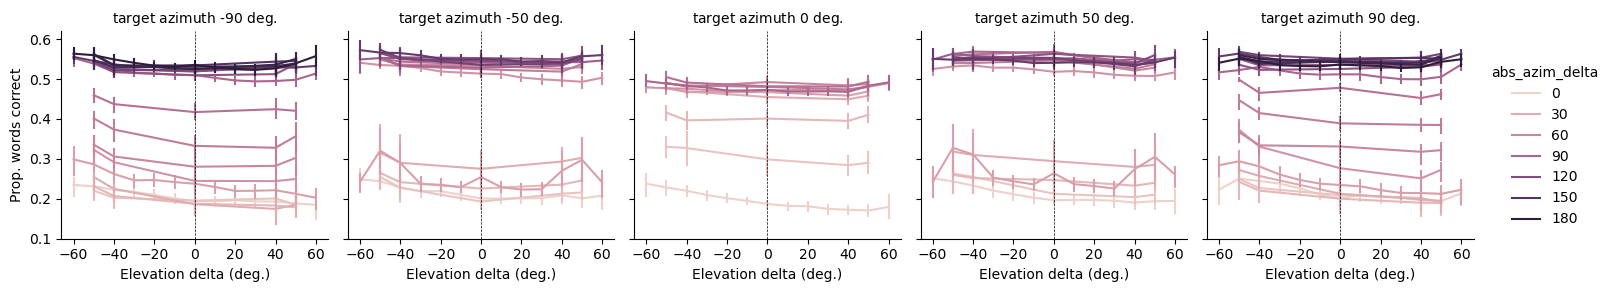

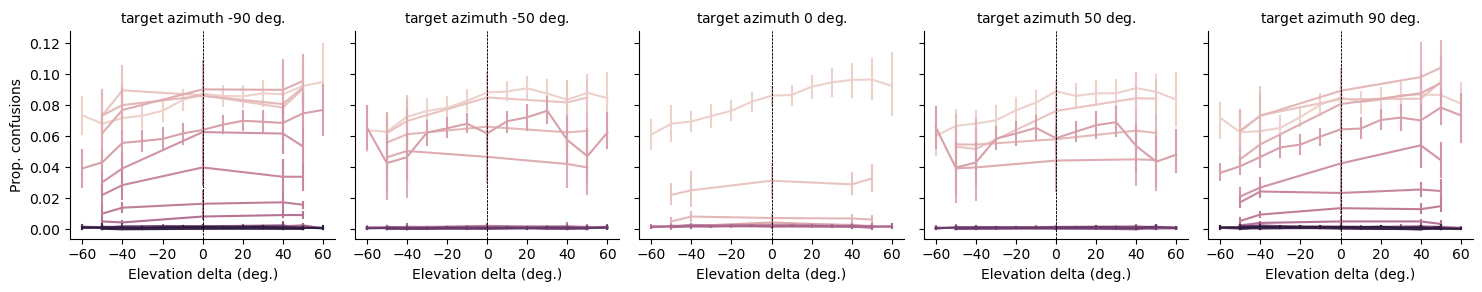

In [20]:

# fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)

# to_plot = results[results.target_azim.isin([0, 30, 60, 90])]
to_plot = results[results.abs_target_azim.isin([0, 50, 90])]
hue_order = ['target', 'distractor', 'co-located']

g = sns.relplot(data=to_plot, x='elevation_sep', y='word_acc', hue='abs_azim_delta', err_style='bars',
                col='target_azim', kind='line', height=3)
# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
g.set_axis_labels("Elevation delta (deg.)", "Prop. words correct")
g.set_titles("target azimuth {col_name} $\deg.$")
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-60, 61, 20),yticks=np.arange(0.1,0.61, 0.1))

# change legend title 
# g.legend.set_title('Abs elveation delta')



g = sns.relplot(data=to_plot, x='elevation_sep', y='confusions', hue='abs_azim_delta', err_style='bars',
                col='target_azim', kind='line',  height=3)
# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)


g.set_axis_labels("Elevation delta (deg.)", "Prop. confusions")
g.set_titles("target azimuth {col_name} $\deg.$")
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-60, 61, 20))
g.legend.remove()
# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)


Text(0, 0.5, 'Confusions')

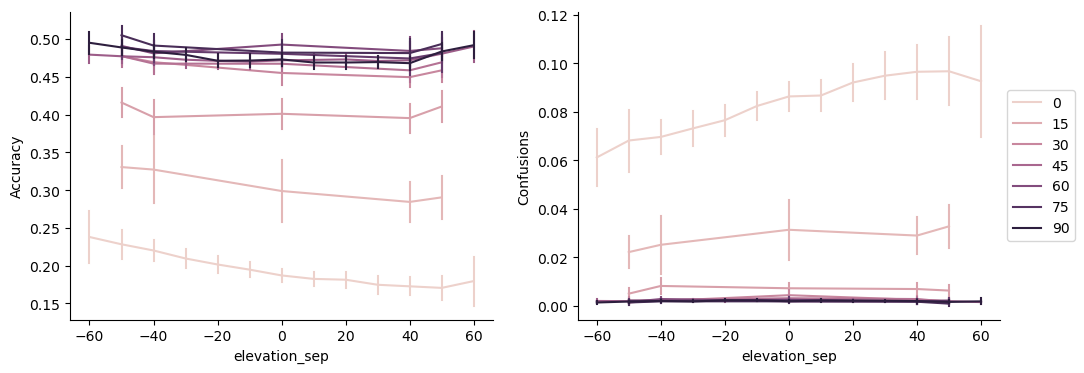

In [48]:
# to_plot = results[results.target_azim == results.distractor_azim ].reset_index(drop=True)
to_plot = results[results.target_azim.isin([0])].reset_index(drop=True)
hue_order = ['target', 'distractor', 'co-located']

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=False)
sns.lineplot(data=to_plot, x='elevation_sep', y='word_acc', ax=axs[0], errorbar=('se', 2),err_style='bars',
               hue='abs_azim_delta', ) #style_order=['target 0 distractor 0', 'target 40 distractor 0', 'target 0 distractor 40'], palette='colorblind') 
sns.lineplot(data=to_plot, x='elevation_sep', y='confusions',  errorbar=('se', 2), err_style='bars',
               ax=axs[1], hue='abs_azim_delta',)# style_order=['target 0 distractor 0', 'target 40 distractor 0', 'target 0 distractor 40'], palette='colorblind')
sns.despine()
# axs[0].set_title("Accuracy")
# axs[1].set_title("Confusions")
# move legend to left of axs[1]
axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axs[0].get_legend().remove()

# make x ticks go -90 to 90
# axs[0].set_xticks(np.arange(0, 91, 30))
# axs[1].set_xticks(np.arange(0, 91, 30))
axs[0].set_ylabel("Accuracy")
axs[1].set_ylabel("Confusions")
# axs[0].set_xlabel("Shared Azimuth")
# axs[1].set_xlabel("Shared Azimuth")




In [26]:

# # fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)

# # make seaborn diverging color palette where 0 is black with 2 colors on either side 
# cmap = sns.diverging_palette(150, 275,  s=80, l=55, as_cmap=True, center='dark')

# # to_plot = results[results.target_azim.isin([0, 30, 60, 90])]
# to_plot = results[results.target_azim.isin([0, -50, -90])]
# hue_order = ['target', 'distractor', 'co-located']

# g = sns.relplot(data=to_plot, x='distractor_azim', y='word_acc', hue='abs_elevation_sep',palette=cmap,
#                 col='target_azim', kind='line', height=3)
# # add x line at 0 
# for ax in g.axes.flatten():
#     ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
# g.set_axis_labels("Distractor azimuth (deg.)", "Prop. words correct")
# g.set_titles("target azimuth {col_name} $\deg.$")
# # set xticks of g from -90 to 90 
# g.set(xticks=np.arange(-90, 91, 30),yticks=np.arange(0.1,0.61, 0.1))

# # change legend title 
# # g.legend.set_title('Abs elveation delta')



# g = sns.relplot(data=to_plot, x='distractor_azim', y='confusions', hue='abs_elevation_sep', palette=cmap,
#                 col='target_azim', kind='line',  height=3)
# # add x line at 0 
# for ax in g.axes.flatten():
#     ax.axvline(0, color='black', linestyle='--', linewidth=0.5)


# g.set_axis_labels("Distractor azimuth (deg.)", "Prop. confusions")
# g.set_titles("target azimuth {col_name} $\deg.$")
# # set xticks of g from -90 to 90 
# g.set(xticks=np.arange(-90, 91, 30))
# g.legend.remove()
# # add x line at 0 
# for ax in g.axes.flatten():
#     ax.axvline(0, color='black', linestyle='--', linewidth=0.5)


/tmp/ipykernel_2016058/1497952644.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['elev_sep_cond'] = to_plot.abs_elevation_sep.apply(lambda x: 'co-located' if x == 0 else 'large' if x >= 20 else 'small')


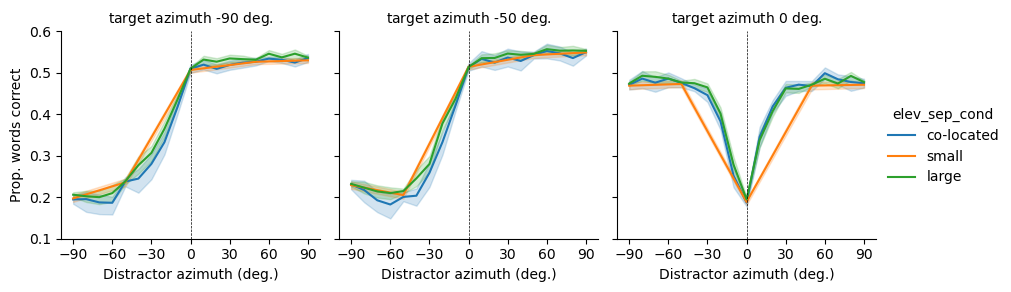

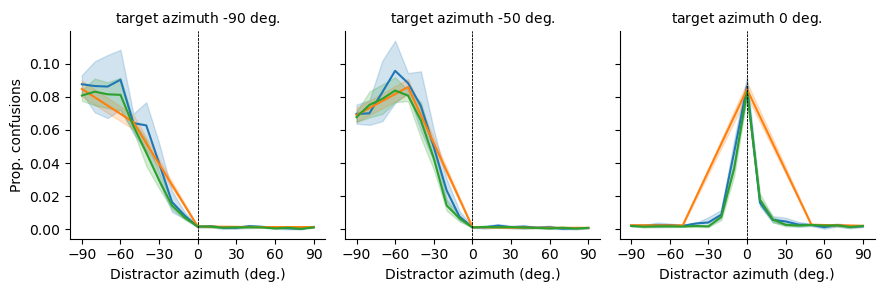

In [33]:

# fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)

# make seaborn diverging color palette where 0 is black with 2 colors on either side 
# cmap = sns.diverging_palette(220, 20, as_cmap=True, center='dark')

# to_plot = results[results.target_azim.isin([0, 30, 60, 90])]
to_plot = results[results.target_azim.isin([0, -50, -90])]

to_plot['elev_sep_cond'] = to_plot.abs_elevation_sep.apply(lambda x: 'co-located' if x == 0 else 'large' if x >= 20 else 'small')

hue_order = ['target', 'distractor', 'co-located']

g = sns.relplot(data=to_plot, x='distractor_azim', y='word_acc', hue='elev_sep_cond',
                col='target_azim', kind='line', height=3)
# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
g.set_axis_labels("Distractor azimuth (deg.)", "Prop. words correct")
g.set_titles("target azimuth {col_name} $\deg.$")
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-90, 91, 30),yticks=np.arange(0.1,0.61, 0.1))

# change legend title 
# g.legend.set_title('Abs elveation delta')



g = sns.relplot(data=to_plot, x='distractor_azim', y='confusions', hue='elev_sep_cond', 
                col='target_azim', kind='line',  height=3)
# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)


g.set_axis_labels("Distractor azimuth (deg.)", "Prop. confusions")
g.set_titles("target azimuth {col_name} $\deg.$")
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-90, 91, 30))
g.legend.remove()
# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)


Text(0.5, 0, 'Azimuth detla')

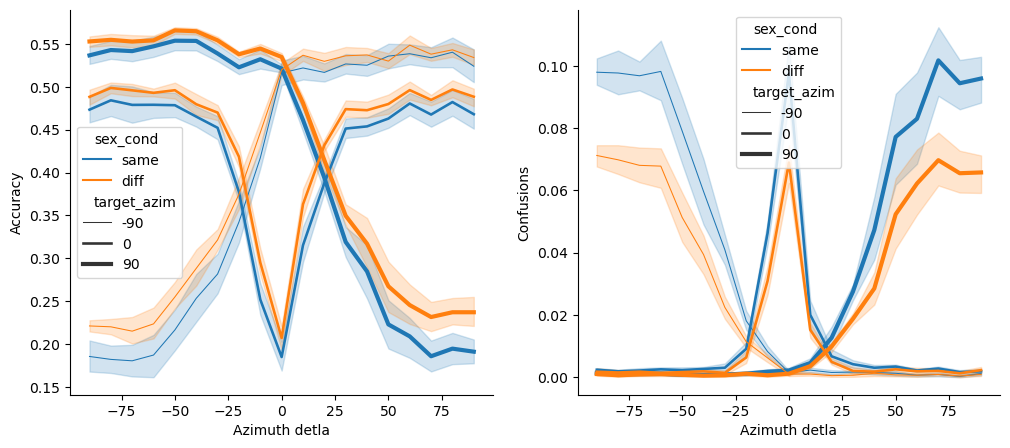

In [53]:
style_order = [0, 90, -90]
to_plot = results[results.target_azim.isin(style_order)].reset_index(drop=True)


fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)
sns.lineplot(data=to_plot, x='distractor_azim', y='word_acc', ax=axs[0], hue='sex_cond', size="target_azim")
sns.lineplot(data=to_plot, x='distractor_azim', y='confusions', hue='sex_cond', size="target_azim", ax=axs[1])
sns.despine()
# axs[0].set_title("Accuracy")
# axs[1].set_title("Confusions")
# make x ticks go -90 to 90
# axs[0].set_xticks(np.arange(0, 91, 30))
# axs[1].set_xticks(np.arange(0, 91, 30))
axs[0].set_ylabel("Accuracy")
axs[1].set_ylabel("Confusions")
axs[0].set_xlabel("Azimuth detla")
axs[1].set_xlabel("Azimuth detla")




In [28]:
## Plot for target at 00 

center_target_cond = results[results.target_azim == 0].reset_index(drop=True)

Text(0.5, 0, 'Distractor Azimuth')

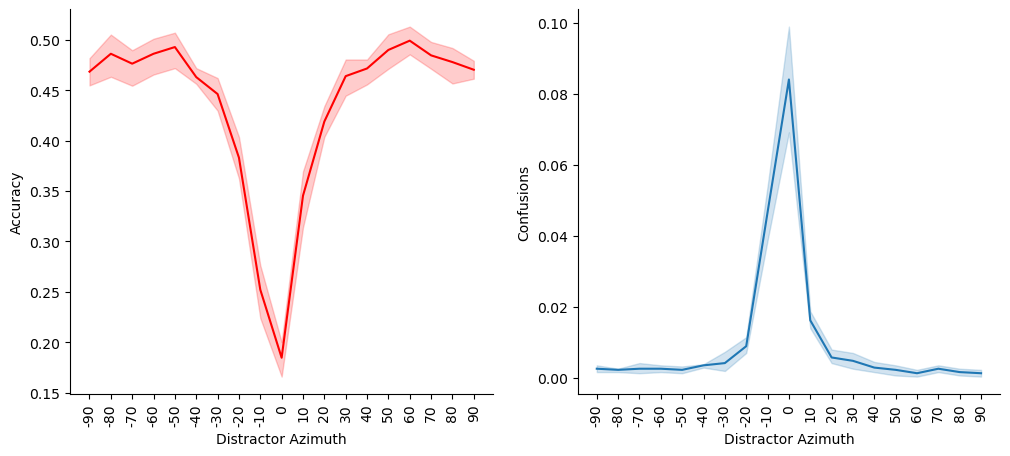

In [29]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)
sns.lineplot(data=center_target_cond, x='distractor_azim', y='word_acc', ax=axs[0], color='red') 
sns.lineplot(data=center_target_cond, x='distractor_azim', y='confusions', ax=axs[1])
sns.despine()
# axs[0].set_title("Accuracy")
# axs[1].set_title("Confusions")
# make x ticks go -90 to 90
axs[0].set_xticks(np.arange(-90, 91, 10),np.arange(-90, 91, 10),rotation=90)
axs[1].set_xticks(np.arange(-90, 91, 10), np.arange(-90, 91, 10),rotation=90)
axs[0].set_ylabel("Accuracy")
axs[1].set_ylabel("Confusions")
axs[0].set_xlabel("Distractor Azimuth")
axs[1].set_xlabel("Distractor Azimuth")




Text(0.5, 0, 'Distractor Azimuth')

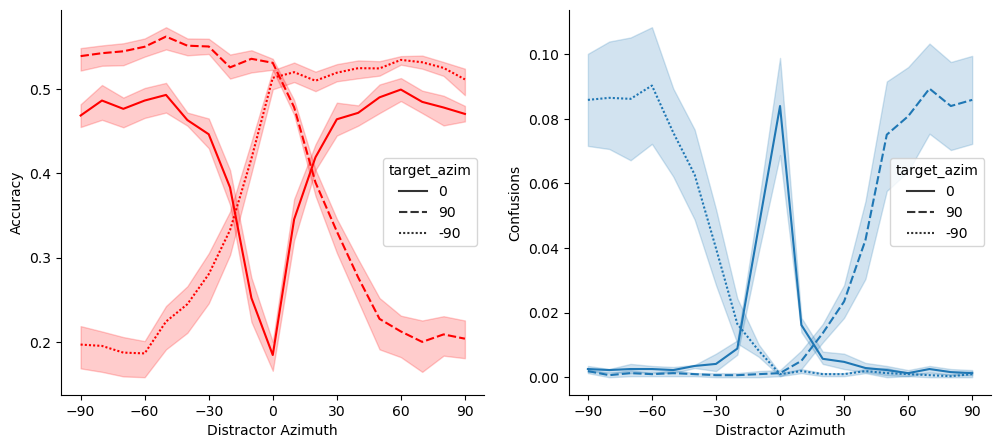

In [30]:
style_order = [0, 90, -90]
to_plot = results[results.target_azim.isin(style_order)].reset_index(drop=True)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)
sns.lineplot(data=to_plot, x='distractor_azim', y='word_acc', ax=axs[0], style='target_azim', style_order=style_order, color='red') 
sns.lineplot(data=to_plot, x='distractor_azim', y='confusions', style='target_azim', style_order=style_order, ax=axs[1])
sns.despine()
# axs[0].set_title("Accuracy")
# axs[1].set_title("Confusions")
# make x ticks go -90 to 90
axs[0].set_xticks(np.arange(-90, 91, 30))
axs[1].set_xticks(np.arange(-90, 91, 30))
axs[0].set_ylabel("Accuracy")
axs[1].set_ylabel("Confusions")
axs[0].set_xlabel("Distractor Azimuth")
axs[1].set_xlabel("Distractor Azimuth")




In [39]:
results

,sex_pairing,target_azim,target_elev,distractor_azim,distractor_elev,word_acc,word_error,confusions,confusion_error,sex_cond,elevation_cond,elevation_sep,abs_elevation_sep,target_elev_dir,elevated_source
0,m_m,0,-10,0,40,0.238276,0.015177,0.078580,0.009586,same,target -10 distractor 40,-50,50,down,distractor
0,m_f,0,-10,0,40,0.230672,0.015007,0.063371,0.008679,diff,target -10 distractor 40,-50,50,down,distractor
0,f_m,0,-10,0,40,0.240811,0.015232,0.049430,0.007722,diff,target -10 distractor 40,-50,50,down,distractor
0,f_f,0,-10,0,40,0.176172,0.013571,0.093790,0.010386,same,target -10 distractor 40,-50,50,down,distractor
0,m_m,0,-10,-10,40,0.314322,0.016538,0.038023,0.006813,same,target -10 distractor 40,-50,50,down,distractor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,f_f,-90,40,-90,-10,0.153359,0.012836,0.106464,0.010987,same,target 40 distractor -10,50,50,up,target
0,m_m,-90,40,-90,0,0.217997,0.014708,0.089987,0.010194,same,target 40 distractor 0,40,40,up,target
0,m_f,-90,40,-90,0,0.223067,0.014830,0.063371,0.008679,diff,target 40 distractor 0,40,40,up,target
0,f_m,-90,40,-90,0,0.210393,0.014520,0.074778,0.009370,diff,target 40 distractor 0,40,40,up,target


Text(0.5, 0, 'Shared Azimuth')

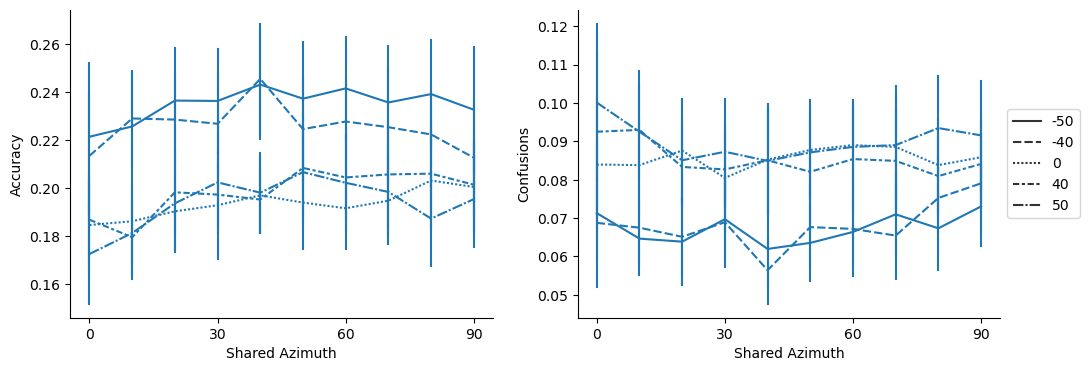

In [64]:
to_plot = results[results.target_azim == results.distractor_azim ].reset_index(drop=True)
hue_order = ['target', 'distractor', 'co-located']
to_plot['joint_azim'] = to_plot.target_azim.abs()
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=False)
sns.lineplot(data=to_plot, x='joint_azim', y='word_acc', ax=axs[0], errorbar=('se', 2),err_style='bars',
               style='elevation_sep', ) #style_order=['target 0 distractor 0', 'target 40 distractor 0', 'target 0 distractor 40'], palette='colorblind') 
sns.lineplot(data=to_plot, x='joint_azim', y='confusions',  errorbar=('se', 2), err_style='bars',
               ax=axs[1], style='elevation_sep',)# style_order=['target 0 distractor 0', 'target 40 distractor 0', 'target 0 distractor 40'], palette='colorblind')
sns.despine()
# axs[0].set_title("Accuracy")
# axs[1].set_title("Confusions")
# move legend to left of axs[1]
axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axs[0].get_legend().remove()

# make x ticks go -90 to 90
axs[0].set_xticks(np.arange(0, 91, 30))
axs[1].set_xticks(np.arange(0, 91, 30))
axs[0].set_ylabel("Accuracy")
axs[1].set_ylabel("Confusions")
axs[0].set_xlabel("Shared Azimuth")
axs[1].set_xlabel("Shared Azimuth")




Text(0.5, 0, 'Shared Azimuth')

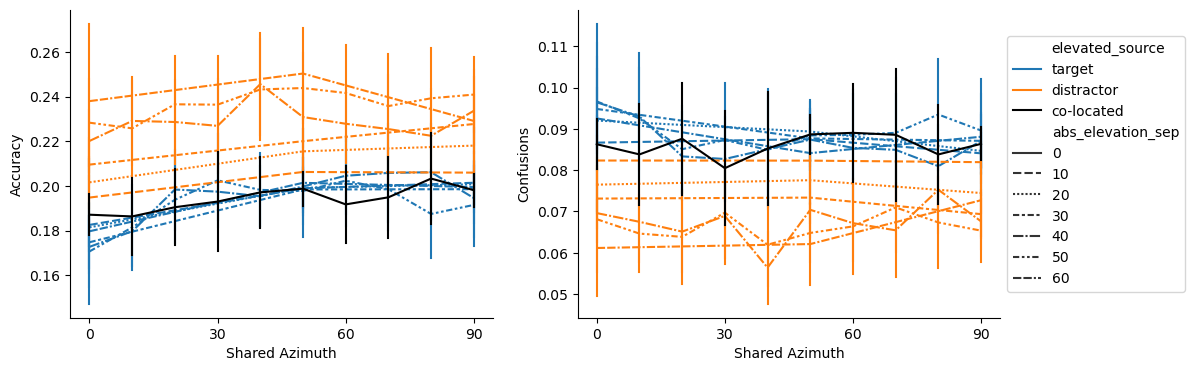

In [35]:
to_plot = results[results.target_azim == results.distractor_azim ].reset_index(drop=True)
hue_order = ['target', 'distractor', 'co-located']
to_plot['joint_azim'] = to_plot.target_azim.abs()
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=False)
sns.lineplot(data=to_plot, x='joint_azim', y='word_acc', ax=axs[0], hue='elevated_source', hue_order=hue_order, palette=['tab:blue', 'tab:orange', 'black'], errorbar=('se', 2),err_style='bars',
               style='abs_elevation_sep', ) #style_order=['target 0 distractor 0', 'target 40 distractor 0', 'target 0 distractor 40'], palette='colorblind') 
sns.lineplot(data=to_plot, x='joint_azim', y='confusions', hue='elevated_source', hue_order=hue_order,palette=['tab:blue', 'tab:orange', 'black'], errorbar=('se', 2), err_style='bars',
               ax=axs[1], style='abs_elevation_sep',)# style_order=['target 0 distractor 0', 'target 40 distractor 0', 'target 0 distractor 40'], palette='colorblind')
sns.despine()
# axs[0].set_title("Accuracy")
# axs[1].set_title("Confusions")
# move legend to left of axs[1]
axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axs[0].get_legend().remove()

# make x ticks go -90 to 90
axs[0].set_xticks(np.arange(0, 91, 30))
axs[1].set_xticks(np.arange(0, 91, 30))
axs[0].set_ylabel("Accuracy")
axs[1].set_ylabel("Confusions")
axs[0].set_xlabel("Shared Azimuth")
axs[1].set_xlabel("Shared Azimuth")




Text(0.5, 0, 'Azimuth delta')

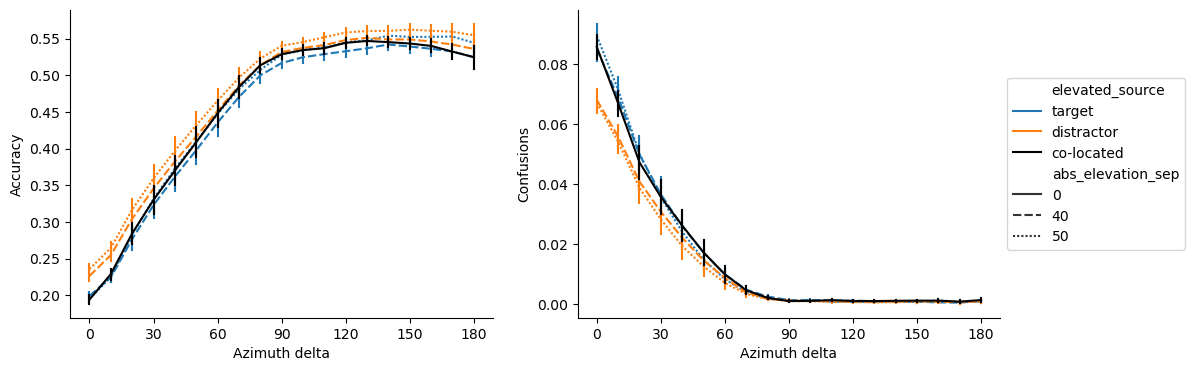

In [74]:
# to_plot = results[results.target_azim == results.distractor_azim ].reset_index(drop=True)
hue_order = ['target', 'distractor', 'co-located']
# to_plot['joint_azim'] = to_plot.target_azim.abs()
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=False)
sns.lineplot(data=results, x='abs_azim_delta', y='word_acc', ax=axs[0], hue='elevated_source', hue_order=hue_order, palette=['tab:blue', 'tab:orange', 'black'], errorbar=('se', 2),err_style='bars',
               style='abs_elevation_sep', ) #style_order=['target 0 distractor 0', 'target 40 distractor 0', 'target 0 distractor 40'], palette='colorblind') 
sns.lineplot(data=results, x='abs_azim_delta', y='confusions', hue='elevated_source', hue_order=hue_order,palette=['tab:blue', 'tab:orange', 'black'], errorbar=('se', 2), err_style='bars',
               ax=axs[1], style='abs_elevation_sep',)# style_order=['target 0 distractor 0', 'target 40 distractor 0', 'target 0 distractor 40'], palette='colorblind')
sns.despine()
# axs[0].set_title("Accuracy")
# axs[1].set_title("Confusions")
# move legend to left of axs[1]
axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axs[0].get_legend().remove()

# make x ticks go -90 to 90
axs[0].set_xticks(np.arange(0, 181, 30))
axs[1].set_xticks(np.arange(0, 181, 30))
axs[0].set_ylabel("Accuracy")
axs[1].set_ylabel("Confusions")
axs[0].set_xlabel("Azimuth delta")
axs[1].set_xlabel("Azimuth delta")




Text(0.5, 0, 'Shared Azimuth')

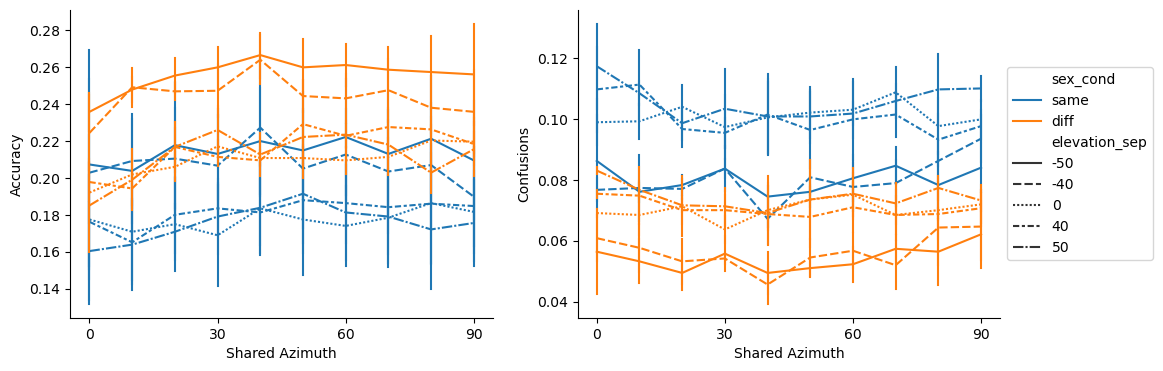

In [24]:
to_plot = results[results.target_azim == results.distractor_azim ].reset_index(drop=True)

to_plot['joint_azim'] = to_plot.target_azim.abs()
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=False)
sns.lineplot(data=to_plot, x='joint_azim', y='word_acc', ax=axs[0], hue='sex_cond', errorbar=('se', 2),err_style='bars',
               style='elevation_sep', ) #style_order=['target 0 distractor 0', 'target 40 distractor 0', 'target 0 distractor 40'], palette='colorblind') 
sns.lineplot(data=to_plot, x='joint_azim', y='confusions', hue='sex_cond', errorbar=('se', 2), err_style='bars',
               ax=axs[1], style='elevation_sep',)# style_order=['target 0 distractor 0', 'target 40 distractor 0', 'target 0 distractor 40'], palette='colorblind')
sns.despine()
# axs[0].set_title("Accuracy")
# axs[1].set_title("Confusions")
# move legend to left of axs[1]
axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axs[0].get_legend().remove()

# make x ticks go -90 to 90
axs[0].set_xticks(np.arange(0, 91, 30))
axs[1].set_xticks(np.arange(0, 91, 30))
axs[0].set_ylabel("Accuracy")
axs[1].set_ylabel("Confusions")
axs[0].set_xlabel("Shared Azimuth")
axs[1].set_xlabel("Shared Azimuth")




Text(0.5, 0, 'Distractor Azimuth')

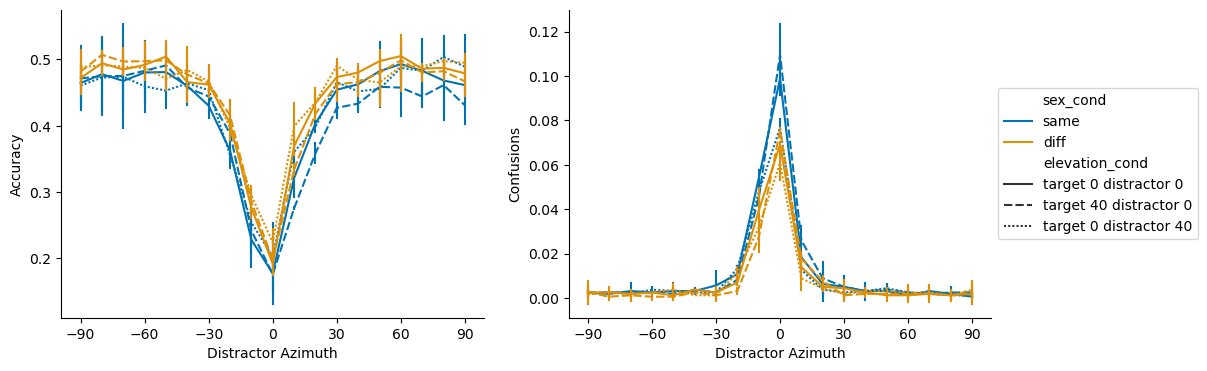

In [57]:
to_plot = results[results.target_azim == 0].reset_index(drop=True)

# to_plot['joint_azim'] = to_plot.target_azim.abs()
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=False)
sns.lineplot(data=to_plot, x='distractor_azim', y='word_acc', ax=axs[0], hue='sex_cond', errorbar=('se', 2),err_style='bars',
               style='elevation_cond', style_order=['target 0 distractor 0', 'target 40 distractor 0', 'target 0 distractor 40'], palette='colorblind') 
sns.lineplot(data=to_plot, x='distractor_azim', y='confusions', hue='sex_cond', errorbar=('se', 2), err_style='bars',
               ax=axs[1], style='elevation_cond', style_order=['target 0 distractor 0', 'target 40 distractor 0', 'target 0 distractor 40'], palette='colorblind')
sns.despine()
# axs[0].set_title("Accuracy")
# axs[1].set_title("Confusions")
# move legend to left of axs[1]
axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axs[0].get_legend().remove()

# make x ticks go -90 to 90
axs[0].set_xticks(np.arange(-90, 91, 30))
axs[1].set_xticks(np.arange(-90, 91, 30))
axs[0].set_ylabel("Accuracy")
axs[1].set_ylabel("Confusions")
axs[0].set_xlabel("Distractor Azimuth")
axs[1].set_xlabel("Distractor Azimuth")




Text(0.5, 0, 'Distractor Azimuth')

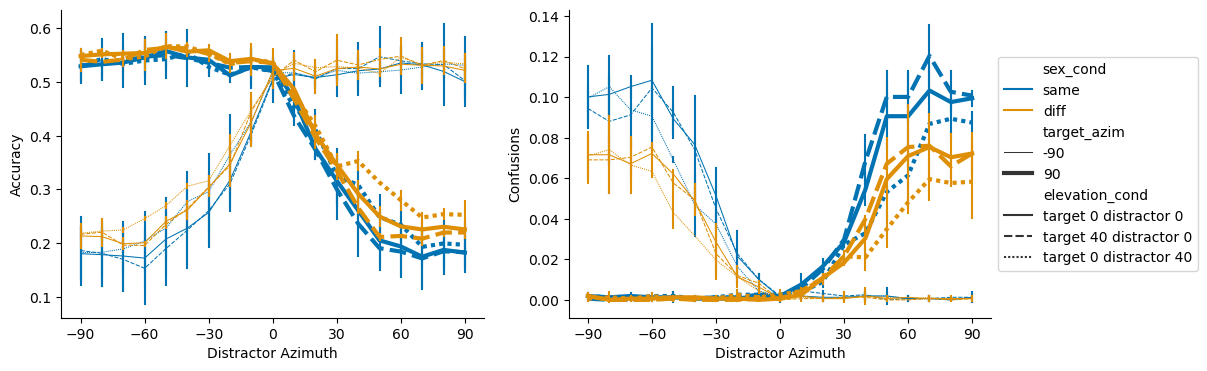

In [60]:
to_plot = results[results.target_azim.isin([90, -90])].reset_index(drop=True)

# to_plot['joint_azim'] = to_plot.target_azim.abs()
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=False)
sns.lineplot(data=to_plot, x='distractor_azim', y='word_acc', ax=axs[0], hue='sex_cond', errorbar=('se', 2),err_style='bars', size='target_azim',
               style='elevation_cond', style_order=['target 0 distractor 0', 'target 40 distractor 0', 'target 0 distractor 40'], palette='colorblind') 
sns.lineplot(data=to_plot, x='distractor_azim', y='confusions', hue='sex_cond', errorbar=('se', 2), err_style='bars',size='target_azim',
               ax=axs[1], style='elevation_cond', style_order=['target 0 distractor 0', 'target 40 distractor 0', 'target 0 distractor 40'], palette='colorblind')
sns.despine()
# axs[0].set_title("Accuracy")
# axs[1].set_title("Confusions")
# move legend to left of axs[1]
axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axs[0].get_legend().remove()

# make x ticks go -90 to 90
axs[0].set_xticks(np.arange(-90, 91, 30))
axs[1].set_xticks(np.arange(-90, 91, 30))
axs[0].set_ylabel("Accuracy")
axs[1].set_ylabel("Confusions")
axs[0].set_xlabel("Distractor Azimuth")
axs[1].set_xlabel("Distractor Azimuth")


